In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
import joblib
folder = "./Preprocessed_data/"
#X_train_encoded = pd.read_parquet(f"{folder}X_Preprocessed_data.parquet"  ,engine='fastparquet')
#X_test_encoded = pd.read_parquet(f"{folder}Y_Preprocessed_data.parquet", engine='fastparquet')

# 2. Load the Preprocessor with Joblib
preprocessor = joblib.load(f"{folder}preprocessor.joblib")

df = pd.read_csv("../Data/Clean_Dataset.csv", index_col=0)
print(df.columns)
df.head()

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='str')


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [7]:
X = df.drop(columns=['price'])
Y = df['price']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


In [2]:
# ════════════════════════════════════════════════
# 7. MODÉLISATION — Comparaison de modèles
# ════════════════════════════════════════════════
from sklearn.dummy        import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble     import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# ── Définir les modèles
models = {
    "Baseline (Dummy)"   : DummyRegressor(strategy="mean"),
    "Régression linéaire": LinearRegression(),
    "Ridge"              : Ridge(alpha=0.5),
    "Random Forest"      : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

In [13]:
# ── Validation croisée 5-fold sur X_train_encoded
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    scores = cross_validate(
        model, X_train_encoded, y_train, cv=cv,
        scoring=["neg_mean_absolute_error",
                 "neg_mean_squared_error",
                 "r2"],
        n_jobs=-1
    )
    results.append({
        "Modèle": name,
        "MAE"   : -scores["test_neg_mean_absolute_error"].mean(),
        "RMSE"  : np.sqrt(-scores["test_neg_mean_squared_error"].mean()),
        "R²"    :  scores["test_r2"].mean(),
    })

results_df = pd.DataFrame(results).set_index("Modèle").round(2)
results_df

,MAE,RMSE,R²
Modèle,,,
Baseline (Dummy),19757.22,22696.16,-0.00
Régression linéaire,4526.46,6819.40,0.91
Ridge,4526.46,6819.40,0.91
Random Forest,1113.96,2775.57,0.99


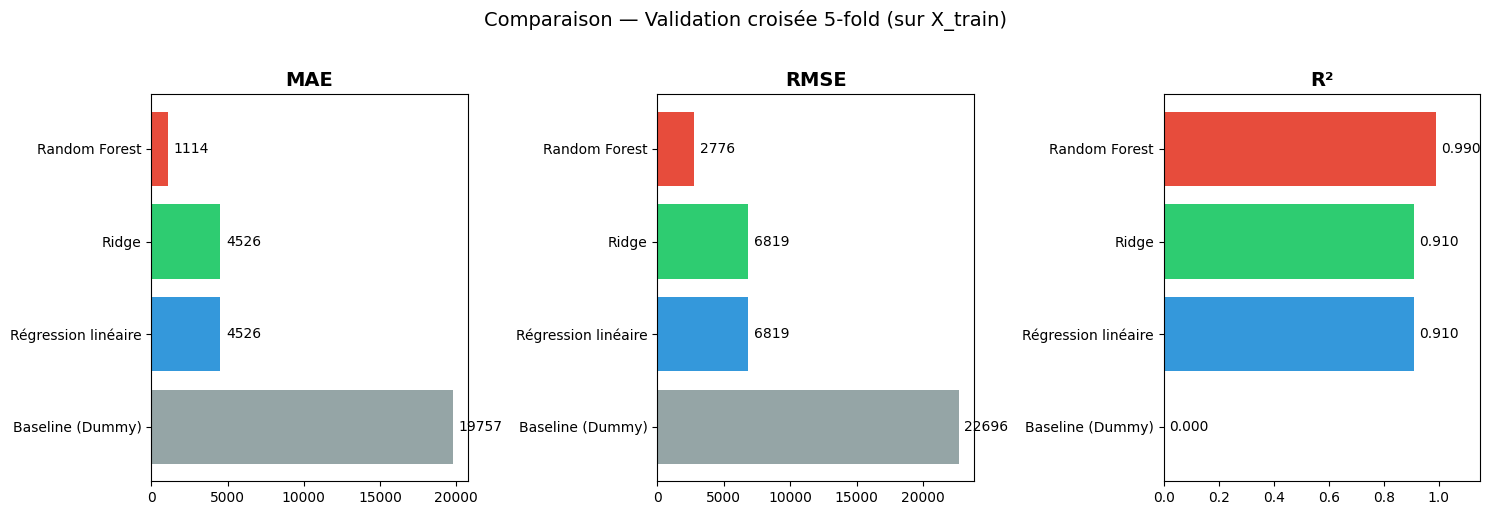

In [15]:
# ── Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#95a5a6", "#3498db", "#2ecc71", "#e74c3c"]

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    bars = ax.barh(results_df.index, results_df[metric], color=colors)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.bar_label(bars, fmt="%.0f" if metric != "R²" else "%.3f", padding=4)
    if metric == "R²":
        ax.set_xlim(0, 1.15)

plt.suptitle("Comparaison — Validation croisée 5-fold (sur X_train)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# ── Évaluation finale sur X_test (hors CV)
print("📊 Évaluation sur X_test\n")
for name, model in models.items():
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)
    mae  = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
    r2   = r2_score(y_test, y_pred)
    print(f"{name:<25} → RMSE: {mae:>8.0f}  |  R²: {r2:.3f}")

📊 Évaluation sur X_test



TypeError: got an unexpected keyword argument 'squared'